# Phase 2: Generating Objective SQI Labels
In Phase 1, we found that the original dataset annotations (based on subject motion) introduce label ambiguity. In this notebook, we calculate a Composite Signal Quality Index (SQI) from the waveform characteristics themselves to build a robust, objective ground truth.

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

project_root = r"c:\Users\rajka\PPG-IIIT"
df = pd.read_csv(os.path.join(project_root, 'outputs', 'extracted_features.csv'))

print(f"Loaded {len(df)} records.")

Loaded 3888 records.


### Calculate the Composite SQI (0 - 100)
We use 4 physical metrics to score the signal.

In [2]:
# 1. Peak Regularity (30 points)
rmssd_score = np.clip(1.0 - (df['rmssd'] / 0.15), 0, 1.0) * 30

# 2. Spectral Entropy (25 points)
entropy_score = np.clip(1.0 - (df['spectral_entropy'] / 4.0), 0, 1.0) * 25

# 3. Peak Detection Reliability (25 points)
peak_score = np.where((df['peak_count'] >= 8) & (df['peak_count'] <= 22), 25, 0)

# 4. Energy Concentration in Heart Rate Band (20 points)
total_power = df['power_low'] + df['power_mid'] + df['power_high'] + 1e-6
hr_band_ratio = (df['power_low'] + df['power_mid']) / total_power
power_score = np.clip(hr_band_ratio, 0, 1.0) * 20

df['SQI_Score'] = rmssd_score + entropy_score + peak_score + power_score
print("SQI Scores Calculated.")

SQI Scores Calculated.


### Map to Balanced Tertiles
We divide the dataset into perfect thirds to guarantee balanced classes for ML.

In [3]:
df['SQI_Label_New'] = pd.qcut(df['SQI_Score'], q=3, labels=['Poor', 'Moderate', 'Good'])

out_path = os.path.join(project_root, 'outputs', 'sqi_labeled_features.csv')
df.to_csv(out_path, index=False)

print("SQI Labeling Complete!\n")
print("Class Distribution:")
print(df['SQI_Label_New'].value_counts())

SQI Labeling Complete!

Class Distribution:
SQI_Label_New
Poor        1296
Moderate    1296
Good        1296
Name: count, dtype: int64


C:\Users\rajka\AppData\Local\Temp\ipykernel_24132\1198723373.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


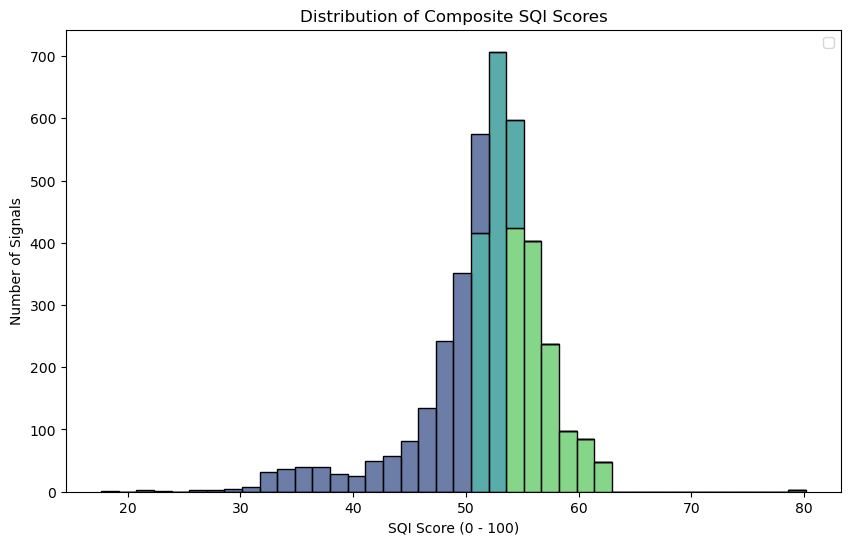

In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='SQI_Score', hue='SQI_Label_New', bins=40, palette='viridis', multiple='stack')
plt.title("Distribution of Composite SQI Scores")
plt.xlabel("SQI Score (0 - 100)")
plt.ylabel("Number of Signals")
plt.legend()
plt.show()